In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Load & Explore datasests

In [2]:
path = "datasets/"

#### transactions

In [3]:
t = pd.read_csv(path + 'transactions.csv')
t.head(3)

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID,AMOUNT_USD
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN
2,GBP,191,COMPLETED,2017-12-10 16:37:16.234,airport,PRT,chip,7bcaa34e-b889-4582-9c29-0b3bab34fb8c,CARD_PAYMENT,GAIA,ddb4a930-7d8a-4f38-9079-ddc4b0db980e,141.0


In [4]:
t.info()

<class 'pandas.DataFrame'>
RangeIndex: 688651 entries, 0 to 688650
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CURRENCY           688651 non-null  str    
 1   AMOUNT             688651 non-null  int64  
 2   STATE              688651 non-null  str    
 3   CREATED_DATE       688651 non-null  str    
 4   MERCHANT_CATEGORY  223065 non-null  str    
 5   MERCHANT_COUNTRY   483055 non-null  str    
 6   ENTRY_METHOD       688651 non-null  str    
 7   USER_ID            688651 non-null  str    
 8   TYPE               688651 non-null  str    
 9   SOURCE             688651 non-null  str    
 10  ID                 688651 non-null  str    
 11  AMOUNT_USD         635328 non-null  float64
dtypes: float64(1), int64(1), str(10)
memory usage: 63.0 MB


In [345]:
# check missing values for MERCHANT_CATEGORY and MERCHANT_COUNTRY
# AMOUNT - no missing values, AMOUNT_USD missing values 

In [5]:
t.describe()

,AMOUNT,AMOUNT_USD
count,6.886510e+05,6.353280e+05
mean,3.172575e+04,6.856953e+03
std,2.304381e+06,7.441684e+04
min,0.000000e+00,0.000000e+00
25%,4.800000e+02,3.590000e+02
50%,1.420000e+03,1.037000e+03
75%,5.000000e+03,3.713000e+03
max,9.000000e+08,1.641211e+07


In [6]:
# t.CREATED_DATE.str.split('.').str[0][0]
# t['datetime'] = pd.to_datetime(t.CREATED_DATE.str.split('.').str[0])
# t['datetime_tail'] = t.CREATED_DATE.str.split('.').str[1]

#### users

In [7]:
u = pd.read_csv(path+'users.csv')
u.head(3)

,ID,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE,STATE,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS
0,1872820f-e3ac-4c02-bdc7-727897b60043,1,GB||JE||IM||GG,False,2018-05-25,2017-08-06 07:33:33.341000,ACTIVE,GB,1971,PASSED,0
1,545ff94d-66f8-4bea-b398-84425fb2301e,1,GB||JE||IM||GG,False,2018-01-01,2017-03-07 10:18:59.427000,ACTIVE,GB,1982,PASSED,0
2,10376f1a-a28a-4885-8daa-c8ca496026bb,1,ES,False,2018-09-20,2018-05-31 04:41:24.672000,ACTIVE,ES,1973,PASSED,0


In [8]:
u.info() 

<class 'pandas.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       9944 non-null   str  
 1   HAS_EMAIL                9944 non-null   int64
 2   PHONE_COUNTRY            9944 non-null   str  
 3   IS_FRAUDSTER             9944 non-null   bool 
 4   TERMS_VERSION            8417 non-null   str  
 5   CREATED_DATE             9944 non-null   str  
 6   STATE                    9944 non-null   str  
 7   COUNTRY                  9944 non-null   str  
 8   BIRTH_YEAR               9944 non-null   int64
 9   KYC                      9944 non-null   str  
 10  FAILED_SIGN_IN_ATTEMPTS  9944 non-null   int64
dtypes: bool(1), int64(3), str(7)
memory usage: 786.7 KB


In [ ]:
sum(u.TERMS_VERSION.isna())
# check TERMS_VERSION distribution of missing values (random?)

1527

In [11]:
u.CREATED_DATE[0]

'2017-08-06 07:33:33.341000'

In [13]:
u.CREATED_DATE = pd.to_datetime(u.CREATED_DATE, format='mixed') #try another aproach with spliting

In [14]:
np.sum(u.IS_FRAUDSTER)

np.int64(298)

In [15]:
u.describe()

,HAS_EMAIL,CREATED_DATE,BIRTH_YEAR,FAILED_SIGN_IN_ATTEMPTS
count,9944.000000,9944,9944.000000,9944.000000
mean,0.946702,2017-10-18 07:39:49.368646,1983.553298,0.008045
min,0.000000,2016-01-03 12:34:05.122000,1927.000000,0.000000
25%,1.000000,2017-06-04 05:25:02.747250,1978.000000,0.000000
50%,1.000000,2018-01-07 16:41:24.968000,1986.000000,0.000000
75%,1.000000,2018-04-28 09:59:36.345750,1992.000000,0.000000
max,1.000000,2018-07-31 13:26:13.492000,2000.000000,6.000000
std,0.224639,NaN,11.350379,0.129737


#### currency

In [16]:
curr = pd.read_csv(path + 'currency_details.csv')
curr.head(3)

,CCY,EXPONENT,IS_CRYPTO
0,AED,2,False
1,AFN,2,False
2,ALL,2,False


In [17]:
curr.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   CCY        184 non-null    str  
 1   EXPONENT   184 non-null    int64
 2   IS_CRYPTO  184 non-null    bool 
dtypes: bool(1), int64(1), str(1)
memory usage: 3.2 KB


#### countries

In [18]:
c = pd.read_csv(path+'countries.csv')
c.head(3)

,CODE,NAME,CODE3,NUMCODE,PHONECODE
0,AF,Afghanistan,AFG,4,93
1,AL,Albania,ALB,8,355
2,DZ,Algeria,DZA,12,213


In [19]:
c.info()

<class 'pandas.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   CODE       225 non-null    str  
 1   NAME       226 non-null    str  
 2   CODE3      226 non-null    str  
 3   NUMCODE    226 non-null    int64
 4   PHONECODE  226 non-null    int64
dtypes: int64(2), str(3)
memory usage: 9.0 KB


# TRANSACTIONS

In [20]:
t.CREATED_DATE[0].split('.')[0]

'2017-12-10 16:38:55'

In [21]:
# pd.to_datetime(t.CREATED_DATE.str.split('.', regex=False).str[0])

In [23]:
t_clean = t.copy()

# convert CREATED_DATE datetime format
t_clean.CREATED_DATE = pd.to_datetime(t_clean.CREATED_DATE, format='mixed')

#let's also add cleaner version of CREATED_DATE (for ts analysis) 
t_clean['datetime'] =  pd.to_datetime(t.CREATED_DATE.str.split('.', regex=False).str[0])
t_clean['date'] =  t_clean.datetime.dt.date

In [24]:
# for distribution analysis of transaction features we need IS_FRAUDSTER labels from users dataset:
t_clean = (t_clean.rename(columns={'ID': 'TRANS_ID'}).merge(u[['ID', 'IS_FRAUDSTER']], left_on='USER_ID', right_on='ID')
        .merge(curr, left_on='CURRENCY', right_on='CCY')
        )
t_clean.columns

Index(['CURRENCY', 'AMOUNT', 'STATE', 'CREATED_DATE', 'MERCHANT_CATEGORY',
       'MERCHANT_COUNTRY', 'ENTRY_METHOD', 'USER_ID', 'TYPE', 'SOURCE',
       'TRANS_ID', 'AMOUNT_USD', 'datetime', 'date', 'ID', 'IS_FRAUDSTER',
       'CCY', 'EXPONENT', 'IS_CRYPTO'],
      dtype='str')

### Amount_USD

* countinuos variable, amount of money for each transaction. For 2 group comparison normalized with log + histogram

In [25]:
fraud_trans = t_clean[t_clean.IS_FRAUDSTER==1]
normal_trans = t_clean[t_clean.IS_FRAUDSTER==0]

In [26]:
fraud_amt = np.log(fraud_trans['AMOUNT_USD'].dropna() + 1)
normal_amt = np.log(normal_trans['AMOUNT_USD'].dropna() + 1)

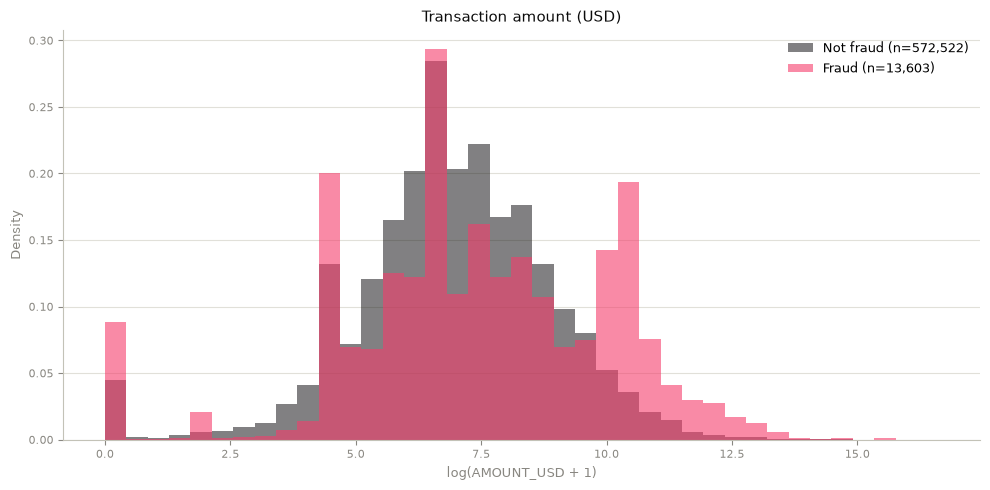

In [25]:
#PLOT

bins = np.linspace(min(fraud_amt.min(), normal_amt.min()),
                    max(fraud_amt.max(), normal_amt.max()), 40)
# d93df5
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(normal_amt, bins=bins, density=True, color="#1a191bff", alpha=0.55,
        label=f'Not fraud (n={len(normal_amt):,})', zorder=2) 
ax.hist(fraud_amt, bins=bins, density=True, color="#f53d6b", alpha=0.60,
        label=f'Fraud (n={len(fraud_amt):,})', zorder=2)

ax.set_title('Transaction amount (USD)', fontsize=11, color='#0b0b0b')
ax.set_xlabel('log(AMOUNT_USD + 1)', fontsize=9, color='#898781')
ax.set_ylabel('Density', fontsize=9, color='#898781')
ax.tick_params(axis='both', labelsize=8, colors='#898781')
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('#c3c2b7')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()


The overlaid density comparison clearly shows fraud transactions cluster at both low amounts and a distinct high-amount bump (~log 10-11) not present in the normal distribution.

In [27]:
# PLOT FUNCTION FOR CATEGORICAL DISTRIBUTION
COLOR_NOT_FRAUD = '#1a191bff'
COLOR_FRAUD = "#f53d6b"

def plot_fraud_crosstab(ct, xlabel, ylabel, title, ax=None, figsize=(10, 5)):

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    colors = [COLOR_FRAUD if col else COLOR_NOT_FRAUD for col in ct.columns]
    ct.plot(kind='bar', width=0.8, color=colors, ax=ax, alpha=0.65)
    
    # ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
    ax.set_xlabel(xlabel, fontsize=9, color='#898781')
    ax.set_ylabel(ylabel, fontsize=9, color='#898781')
    ax.set_title(title, fontsize=11, color='#0b0b0b')
    ax.tick_params(axis='both', labelsize=8, colors='#898781')
    ax.tick_params(axis='x', labelrotation=0)
    
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')
    ax.legend(['Non-fraudster', 'Fraudster'], frameon=False, fontsize=9)
    ax.figure.tight_layout()
    return ax


### STATE



In [28]:
t_clean['STATE'].unique()

<StringArray>
['COMPLETED',  'REVERTED',  'DECLINED',    'FAILED', 'CANCELLED',   'PENDING',
  'RECORDED']
Length: 7, dtype: str

<Axes: title={'center': 'feature STATE'}, xlabel='State', ylabel='Proportion'>

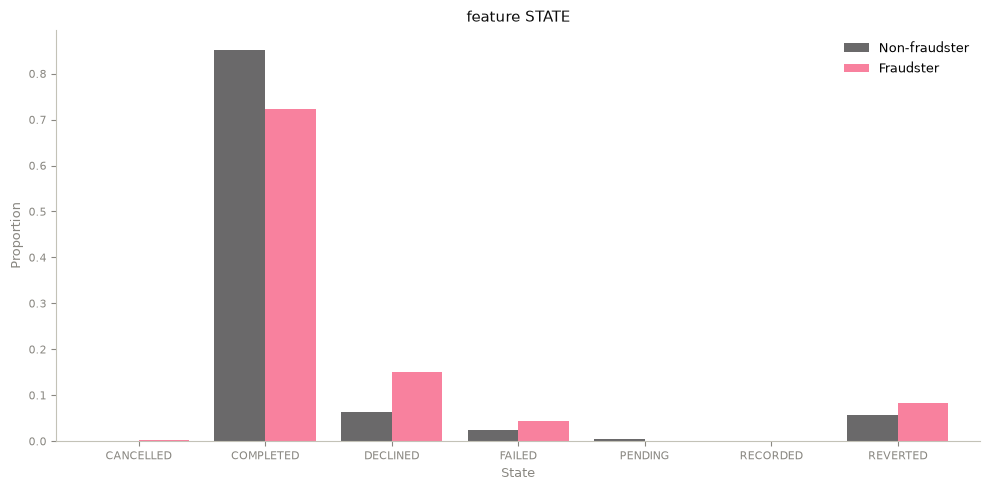

In [29]:
ct = pd.crosstab(t_clean['STATE'], t_clean['IS_FRAUDSTER'], normalize='columns')
plot_fraud_crosstab(ct, xlabel='State', ylabel='Proportion',
                     title='feature STATE')


In [30]:
ct.sort_values(True, ascending=False)*100

IS_FRAUDSTER,False,True
STATE,,
COMPLETED,85.251141,72.250970
DECLINED,6.241238,15.071151
REVERTED,5.644113,8.200374
FAILED,2.400501,4.290643
CANCELLED,0.074901,0.143740
PENDING,0.387947,0.043122
RECORDED,0.000160,0.000000


### MERCHANT_CATEGORY
####  where the transaction happened

In [31]:
print(f"Missing merchant categories: {round(np.sum(t_clean.MERCHANT_CATEGORY.isna())/len(t_clean.MERCHANT_CATEGORY)*100)}% ")
# a huge percentage of missing values

Missing merchant categories: 67% 


In [32]:
merch_cat = t_clean.MERCHANT_CATEGORY.isna().map({True:'missing', False: 'present'})
pd.crosstab(t_clean.TYPE, merch_cat, normalize='index').sort_values('present')*100

MERCHANT_CATEGORY,missing,present
TYPE,,
BANK_TRANSFER,100.000000,0.000000
P2P,100.000000,0.000000
TOPUP,100.000000,0.000000
ATM,65.289276,34.710724
CARD_PAYMENT,52.122144,47.877856


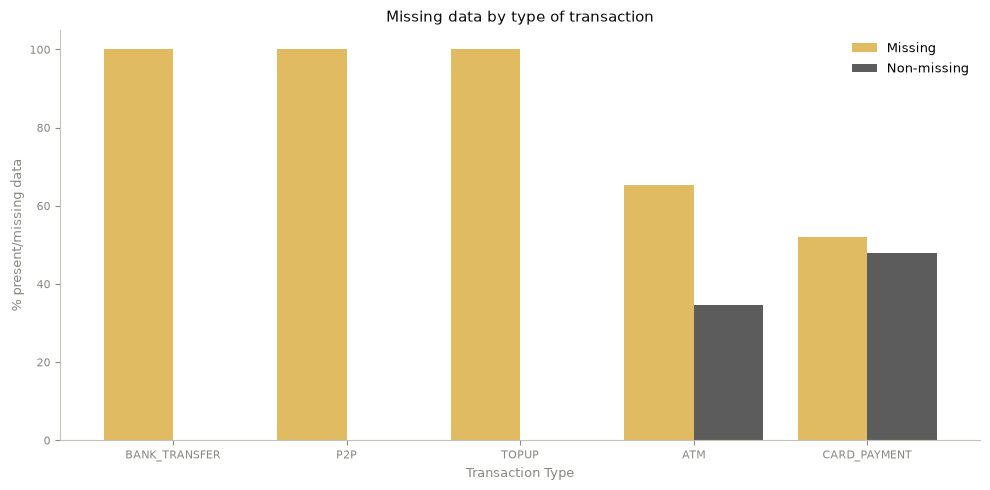

In [33]:
ct_merch = pd.crosstab(t_clean.TYPE, merch_cat, normalize='index').sort_values('present')*100
_, ax = plt.subplots(figsize=(10, 5))

colors = ["#d2970d", "#040404"]

ct_merch.plot(kind='bar', width=0.8, color=colors, ax=ax, alpha=0.65)

# ax.grid(axis='y', color='#e1e0d9', linewidth=0.1, zorder=0)
ax.set_xlabel('Transaction Type', fontsize=9, color='#898781')
ax.set_ylabel('% present/missing data', fontsize=9, color='#898781')
ax.set_title('Missing data by type of transaction', fontsize=11, color='#0b0b0b')
ax.tick_params(axis='both', labelsize=8, colors='#898781')
ax.tick_params(axis='x', labelrotation=0)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('#c3c2b7')
ax.legend(['Missing', 'Non-missing'], frameon=False, fontsize=9)
ax.figure.tight_layout()

plt.show()
# add percantages on bars!!!

In [34]:
# So it is evidentally structural missing so called
# MNAR Missing Not At Random
# as it is structural let's populate it with NO_MERCHANT category for these 3 TYPEs of transaction

t_clean.loc[t_clean.MERCHANT_CATEGORY.isin(['BANK_TRANSFER', 'P2P', 'TOPUP']), 'MERCHANT_CATEGORY'] = t_clean.loc[t_clean.MERCHANT_CATEGORY.isin(['BANK_TRANSFER', 'P2P', 'TOPUP']), 'MERCHANT_CATEGORY'].fillna('NO_MERCHANT')

In [35]:
#let's check the real missings from t_clean for MERCHANT_CATEGORY and TYPEs ATM/CARD_PAYMENT
merch_cat_new = t_clean.MERCHANT_CATEGORY.isna().map({True:'missing', False: 'present'})
pd.crosstab(t_clean.TYPE, merch_cat_new, normalize='index').sort_values('present')*100

MERCHANT_CATEGORY,missing,present
TYPE,,
BANK_TRANSFER,100.000000,0.000000
P2P,100.000000,0.000000
TOPUP,100.000000,0.000000
ATM,65.289276,34.710724
CARD_PAYMENT,52.122144,47.877856


In [36]:
# we still we have suspicious lange amount of missing data for ATM and CARD_PAYMENT for merchant_category. Looks like structural problem. 
# Let's fill it with "missing"
t_clean.loc[t_clean.MERCHANT_CATEGORY.isna(), 'MERCHANT_CATEGORY'] = t_clean.loc[t_clean.MERCHANT_CATEGORY.isna(), 'MERCHANT_CATEGORY'].fillna('missing')

In [37]:
t_clean.head(3)

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,TRANS_ID,AMOUNT_USD,datetime,date,ID,IS_FRAUDSTER,CCY,EXPONENT,IS_CRYPTO
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,missing,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0,2017-12-10 16:38:55,2017-12-10,3ff52b92-d416-4e22-8cad-018f500d4bbc,False,GBP,2,False
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN,2017-12-10 16:37:24,2017-12-10,76cbaad3-4721-4a3b-92b9-3eb9e9319565,False,PLN,2,False
2,GBP,10000,COMPLETED,2017-12-10 16:34:42.592,missing,NaN,misc,b3a6762b-a940-4459-bb1d-8e28e151f901,TOPUP,HERA,080ef0be-850a-4f14-ab03-28ff68e6b797,7394.0,2017-12-10 16:34:42,2017-12-10,b3a6762b-a940-4459-bb1d-8e28e151f901,False,GBP,2,False


### MERCHANT_COUNTRY

In [38]:
# let's do the same for MERCHANT_COUNTRY

In [39]:
print(f"missings in MERCHANT_COUNTRY: {round(np.sum(t_clean.MERCHANT_COUNTRY.isna())*100/t_clean.shape[0], 2)}%")

missings in MERCHANT_COUNTRY: 30.02%


In [40]:
merch_country = t_clean.MERCHANT_COUNTRY.isna().map({True:'missing', False: 'present'})
merch_country[:3]

0    present
1    present
2    missing
Name: MERCHANT_COUNTRY, dtype: str

In [41]:
# ct_merch_country = 
pd.crosstab(t_clean.TYPE, merch_country, normalize='index').sort_values('present')*100 

MERCHANT_COUNTRY,missing,present
TYPE,,
BANK_TRANSFER,100.000000,0.000000
P2P,100.000000,0.000000
TOPUP,100.000000,0.000000
ATM,0.224470,99.775530
CARD_PAYMENT,0.033759,99.966241


In [42]:
# Here we see that there are just 0.224470	and 0.033759 % missing data for ATM and CARD_PAYMENT type respectively. 
# Let's first put NA strings to stuctural NAs and then fill the missing data fro ATM and CARD_PAYMENT with some statistics.

In [43]:
t_clean.MERCHANT_COUNTRY = np.where(t_clean.TYPE.isin(['BANK_TRANSFER', 'P2P', 'TOPUP']), 'NO_COUNTRY', t_clean.MERCHANT_COUNTRY)

In [44]:
print(f"missings in MERCHANT_COUNTRY: {round(np.sum(t_clean.MERCHANT_COUNTRY.isna())*100/t_clean.shape[0], 2)}%")

missings in MERCHANT_COUNTRY: 0.04%


In [45]:
t_clean.MERCHANT_COUNTRY.isna().values

array([False, False, False, ..., False, False, False], shape=(638742,))

In [46]:
pd.crosstab(t_clean.TYPE, t_clean.MERCHANT_COUNTRY.isna(), normalize='index').sort_values(True)

MERCHANT_COUNTRY,False,True
TYPE,,
BANK_TRANSFER,1.000000,0.000000
P2P,1.000000,0.000000
TOPUP,1.000000,0.000000
CARD_PAYMENT,0.999662,0.000338
ATM,0.997755,0.002245


In [47]:
# we still want to keep this information about missing values, as it could be some signal. So let's populate it with "N/A"
t_clean.MERCHANT_COUNTRY = np.where(t_clean.MERCHANT_COUNTRY.isna(), 'N/A', t_clean.MERCHANT_COUNTRY)
# real_merch_country_missings

### ENTRY_METHOD 

In [48]:
t_clean.ENTRY_METHOD.unique()

<StringArray>
['chip', 'manu', 'misc', 'cont', 'mags', 'mcon']
Length: 6, dtype: str

<Axes: title={'center': 'Entry method distribution by fraud status'}, xlabel='Entry method', ylabel='Proportion'>

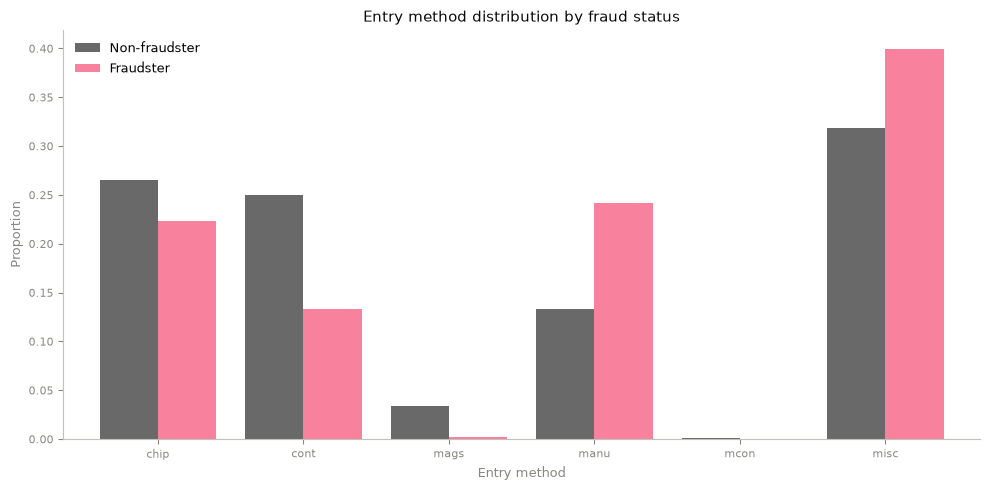

In [49]:
ct_entry_method = pd.crosstab(t_clean.ENTRY_METHOD, t_clean.IS_FRAUDSTER, normalize='columns')
plot_fraud_crosstab(ct_entry_method, xlabel='Entry method', ylabel='Proportion',
                     title='Entry method distribution by fraud status')



### TYPE

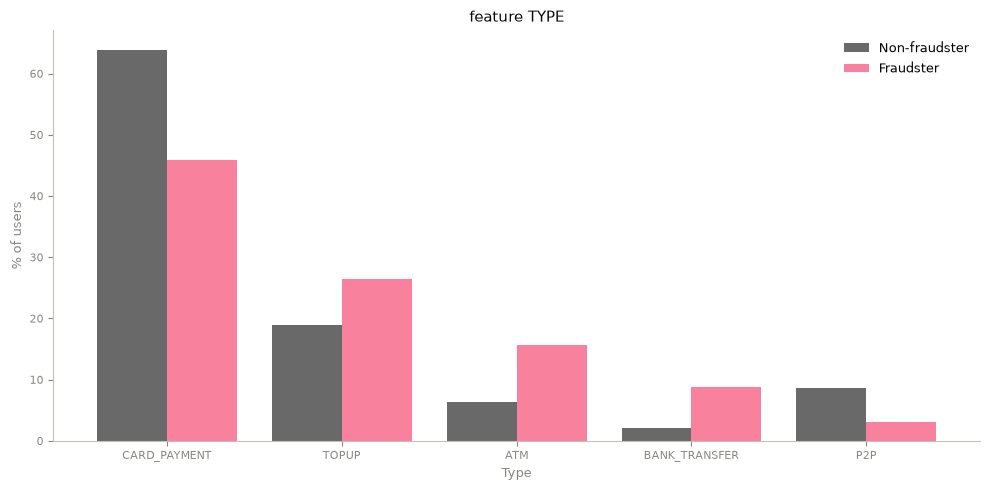

In [50]:
ct_type = (pd.crosstab(t_clean.TYPE, t_clean.IS_FRAUDSTER, normalize='columns')*100).sort_values(True, ascending=False)
plot_fraud_crosstab(ct_type, xlabel='Type', ylabel='% of users',
                     title='feature TYPE')
plt.show()


### SOURCE

<Axes: title={'center': 'feature SOURCE'}, xlabel='Source', ylabel='% of users'>

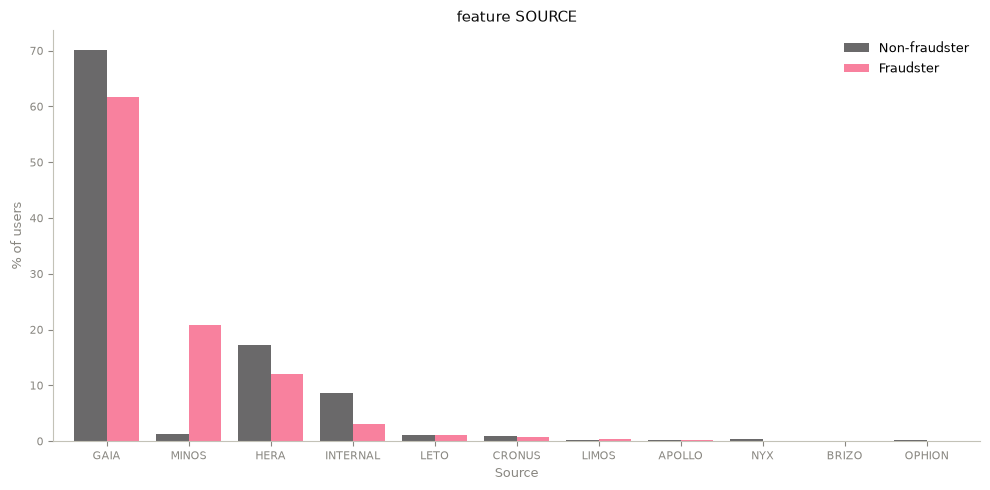

In [51]:
ct_source = (pd.crosstab(t_clean.SOURCE, t_clean.IS_FRAUDSTER, normalize='columns')*100).sort_values(True, ascending=False)
plot_fraud_crosstab(ct_source, xlabel='Source', ylabel='% of users',
                     title='feature SOURCE')



### CREATE_DATE - TIME ANALYSIS

I can asume that timing could play a big role in anomaly detection. But it could be also my own bias from time series analysis background. Newetherless i want to explore this field. 

In [52]:
fraud_ids = fraud_trans.USER_ID.unique()
normal_ids = normal_trans.USER_ID.unique()

In [55]:
# TIME SERIES PLOTS
COLOR_NOT_FRAUD = '#1a191bff'
COLOR_FRAUD = "#f53d6b"

def get_user_series(t_clean, user_id, date_col='datetime', amount_col='AMOUNT'):
    """Return one user's transactions as a datetime-indexed, time-sorted Series."""
    s = t_clean.loc[t_clean.USER_ID == user_id, [date_col, amount_col]]
    return s.sort_values(date_col).set_index(date_col)[amount_col]


def plot_user_timeseries(series, ax, color='#2a78d6', title=None):
    """Plot one user's AMOUNT time series (as returned by get_user_series) on ax."""
    ax.plot(series.index, series.values, color=color, linewidth=1.5,
            marker='o', markersize=3)

    ax.set_title(title, fontsize=9, color='#0b0b0b')
    ax.tick_params(axis='x', labelrotation=30, labelsize=7, colors='#898781')
    ax.tick_params(axis='y', labelsize=7, colors='#898781')
    ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')


def plot_user_grid(t_clean, not_fraud_ids, fraud_ids, n=6):
    """Plot n not-fraud users (left, 2 cols) and n fraud users (right, 2 cols)
    side by side in one figure, one subplot per user."""
    nrows = int(np.ceil(n / 2))
    fig, axes = plt.subplots(nrows, 4, figsize=(16, 2.5 * nrows))

    groups = [(not_fraud_ids, COLOR_NOT_FRAUD, 'Not fraud', 0), (fraud_ids, COLOR_FRAUD, 'Fraud', 2)]
    for ids, color, label, col_offset in groups:
        for i, uid in enumerate(list(ids)[:n]):
            row, col = divmod(i, 2)
            plot_user_timeseries(get_user_series(t_clean, uid), ax=axes[row, col_offset + col],
                                  color=color, title=uid[:8])
        fig.text(0.27 if col_offset == 0 else 0.73, 0.98, label,
                  fontsize=13, color=color, fontweight='bold', ha='center')

    fig.suptitle(f'Transaction amount over time — not-fraud vs fraud (n={n} each)',
                 fontsize=13, color='#0b0b0b', y=1.04)
    fig.tight_layout()

In [53]:
t_clean.columns

Index(['CURRENCY', 'AMOUNT', 'STATE', 'CREATED_DATE', 'MERCHANT_CATEGORY',
       'MERCHANT_COUNTRY', 'ENTRY_METHOD', 'USER_ID', 'TYPE', 'SOURCE',
       'TRANS_ID', 'AMOUNT_USD', 'datetime', 'date', 'ID', 'IS_FRAUDSTER',
       'CCY', 'EXPONENT', 'IS_CRYPTO'],
      dtype='str')

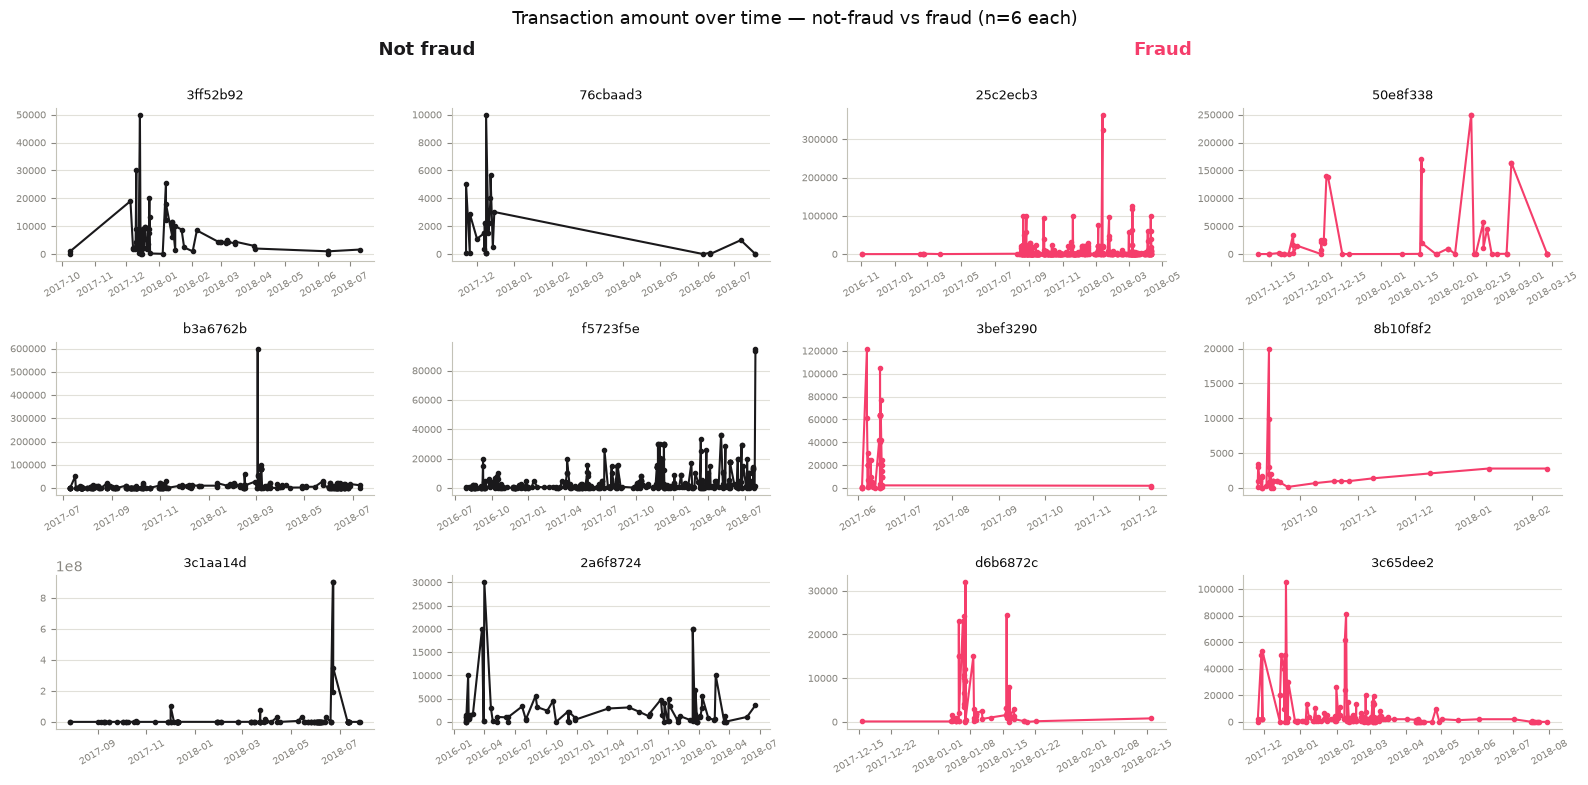

In [56]:
plot_user_grid(t_clean, normal_ids, fraud_ids, n=6)


## CURRENCY_DETAILS

In [57]:
curr.columns

Index(['CCY', 'EXPONENT', 'IS_CRYPTO'], dtype='str')

### IS_CRYPTO

In [58]:
# let's check wether crypto currency doesn't have give any obvious signals 
pd.crosstab(t_clean.IS_CRYPTO, t_clean.IS_FRAUDSTER)

IS_FRAUDSTER,False,True
IS_CRYPTO,,
False,624260,13911
True,568,3


In [59]:
# there is tiny fraction of fraudesters in crypto cluster. 
t_clean = t_clean.drop(['CCY', 'EXPONENT'], axis=1)

# USERS

In [60]:
u.info()

<class 'pandas.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       9944 non-null   str           
 1   HAS_EMAIL                9944 non-null   int64         
 2   PHONE_COUNTRY            9944 non-null   str           
 3   IS_FRAUDSTER             9944 non-null   bool          
 4   TERMS_VERSION            8417 non-null   str           
 5   CREATED_DATE             9944 non-null   datetime64[us]
 6   STATE                    9944 non-null   str           
 7   COUNTRY                  9944 non-null   str           
 8   BIRTH_YEAR               9944 non-null   int64         
 9   KYC                      9944 non-null   str           
 10  FAILED_SIGN_IN_ATTEMPTS  9944 non-null   int64         
dtypes: bool(1), datetime64[us](1), int64(3), str(6)
memory usage: 786.7 KB


### HAS_EMAIL

<Axes: title={'center': 'feature HAS_EMAIL'}, xlabel='State', ylabel='Proportion'>

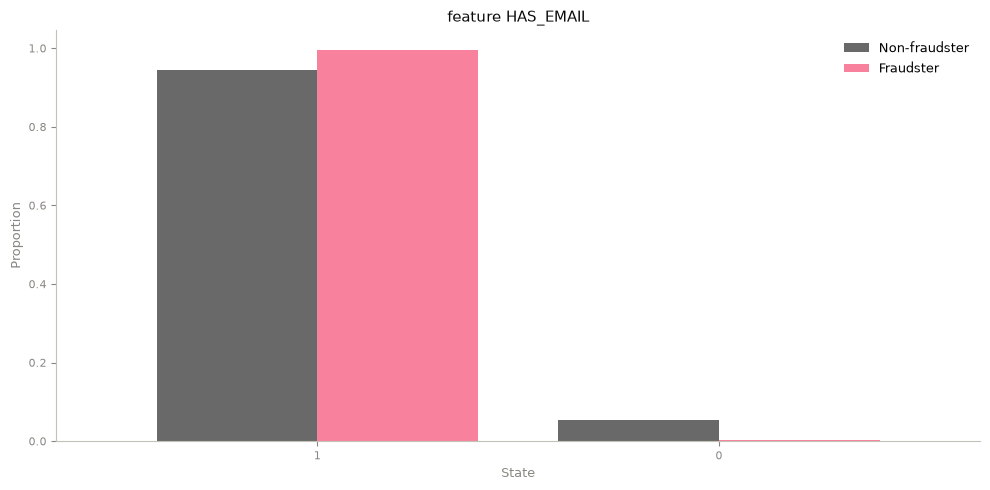

In [61]:
ct_email = pd.crosstab(u.HAS_EMAIL, u.IS_FRAUDSTER, normalize='columns').sort_values(True, ascending=False)
plot_fraud_crosstab(ct_email, xlabel='State', ylabel='Proportion',
                     title='feature HAS_EMAIL')

In [111]:
# fraudsters prevail in using_email. maybe because it's simplier for the fraud process than phone. 
# and ligitimate users less bother themselvs with providing email, rather operate with phone auth etc.

### PHONE_COUNTRY

In [62]:
u.PHONE_COUNTRY.unique()

<StringArray>
['GB||JE||IM||GG',             'ES',             'FR',             'SI',
             'PL',             'BE',             'CH',             'CZ',
             'GR',         'FI||AX',             'CY',             'IE',
             'LT',     'US||PR||CA',             'MT',             'HU',
             'RO',             'DK',             'MY',             'DE',
             'HR',             'BG',             'PT',         'RU||KZ',
             'MK',     'NO||SJ||BV',             'IT',             'EE',
             'LV',             'SE',             'JO',             'SK',
             'NL',             'AD',             'AT',             'IN',
             'NC',             'ZA',             'LU',             'GI',
             'IS',             'ME',             'BR',             'MX',
     'CC||CX||AU',             'NZ',             'TH',             'ID',
         'EH||MA',             'TR',             'OM',     'BL||MF||GP',
             'GF',             'GE', 

In [63]:
# there are some codes that contain more than 1 code, it could be problematic. Let's filter them:
mask=u.PHONE_COUNTRY.str.split('||', regex=False).str.len()>1
u[mask].head(3)

,ID,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE,STATE,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS
0,1872820f-e3ac-4c02-bdc7-727897b60043,1,GB||JE||IM||GG,False,2018-05-25,2017-08-06 07:33:33.341,ACTIVE,GB,1971,PASSED,0
1,545ff94d-66f8-4bea-b398-84425fb2301e,1,GB||JE||IM||GG,False,2018-01-01,2017-03-07 10:18:59.427,ACTIVE,GB,1982,PASSED,0
4,755fe256-a34d-4853-b7ca-d9bb991a86d3,1,GB||JE||IM||GG,False,2018-09-20,2017-08-09 15:03:33.945,ACTIVE,GB,1989,PASSED,0


In [64]:
u[mask].groupby('PHONE_COUNTRY')['IS_FRAUDSTER'].agg(['sum', 'count'])

,sum,count
PHONE_COUNTRY,,
BL||MF||GP,0,3
CC||CX||AU,0,14
EH||MA,0,5
FI||AX,0,17
GB||JE||IM||GG,263,4302
NO||SJ||BV,0,32
RU||KZ,0,12
TF||RE||YT,0,3
US||PR||CA,2,20


In [65]:
pd.crosstab(u[mask]['PHONE_COUNTRY'], u[mask]['IS_FRAUDSTER'], normalize='columns')*100 #there is no signal for grouped codes. 

IS_FRAUDSTER,False,True
PHONE_COUNTRY,,
BL||MF||GP,0.072411,0.000000
CC||CX||AU,0.337919,0.000000
EH||MA,0.120685,0.000000
FI||AX,0.410331,0.000000
GB||JE||IM||GG,97.489742,99.245283
NO||SJ||BV,0.772387,0.000000
RU||KZ,0.289645,0.000000
TF||RE||YT,0.072411,0.000000
US||PR||CA,0.434468,0.754717


In [66]:
# the last filter to check it's whether country is in the phone code sequence for fraud/legal. 
u_filtered = (u[mask]
    .loc[lambda d: [c not in str(p).split('||') for c, p in zip(d.COUNTRY, d.PHONE_COUNTRY)]])

pd.crosstab(u_filtered.PHONE_COUNTRY, u_filtered.IS_FRAUDSTER)

IS_FRAUDSTER,False,True
PHONE_COUNTRY,,
BL||MF||GP,2,0
CC||CX||AU,13,0
EH||MA,5,0
GB||JE||IM||GG,40,1
NO||SJ||BV,2,0
RU||KZ,9,0
US||PR||CA,18,2


In [117]:
# for simplicity we can replace grouped codes with COUNTRY for: not fraudsters, where the country code in PHONE_COUNTRY sequence. 


In [67]:
u_clean = u.copy()

In [68]:

in_phone_code = pd.Series(
    [c in str(p).split('||') for c, p in zip(u_clean.COUNTRY, u_clean.PHONE_COUNTRY)],
    index=u_clean.index,
)

cond = mask & in_phone_code & ~u_clean.IS_FRAUDSTER

u_clean.loc[cond, 'PHONE_COUNTRY'] = u_clean.loc[cond, 'COUNTRY']

### TERMS_VERSION

In [69]:
# as we ses this feature has decent amount of missing values
print(f"{round(sum(u_clean.TERMS_VERSION.isna())/u_clean.shape[0]*100, 2)}%")

15.36%


<Axes: title={'center': 'TERMS_VERSION by fraud status'}, xlabel='TERMS_VERSION', ylabel='Proportion'>

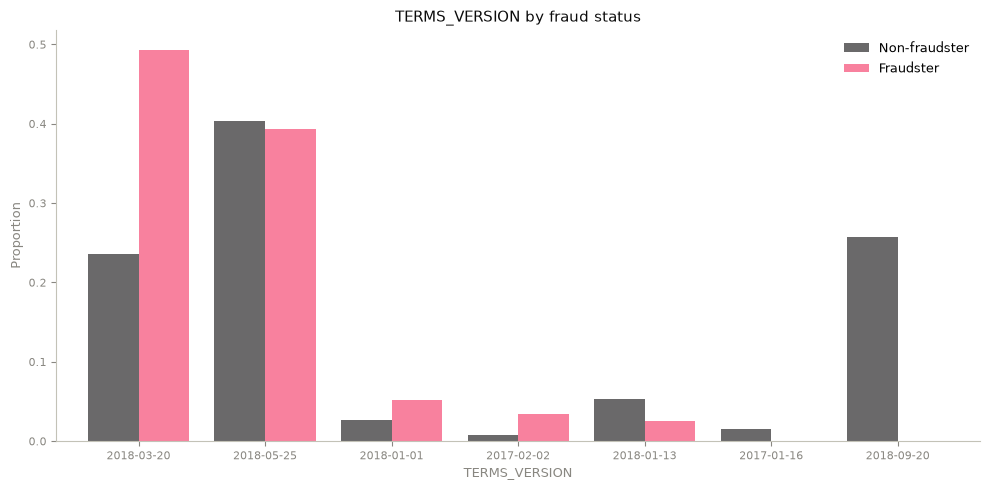

In [70]:
ct_terms = pd.crosstab(u_clean.TERMS_VERSION, u_clean.IS_FRAUDSTER, normalize='columns').sort_values(True, ascending=False)
plot_fraud_crosstab(ct_terms, xlabel='TERMS_VERSION', ylabel='Proportion',
                     title='TERMS_VERSION by fraud status')

In [122]:
# we see that fraudsters havily operates on terms version from 2018-03-20 and 2018-05-25

In [71]:
# let's check missing values:
ct_terms_missed = pd.crosstab(u_clean.TERMS_VERSION.isna(), u_clean.IS_FRAUDSTER, normalize='columns')*100
ct_terms_missed

IS_FRAUDSTER,False,True
TERMS_VERSION,,
False,84.864192,77.516779
True,15.135808,22.483221


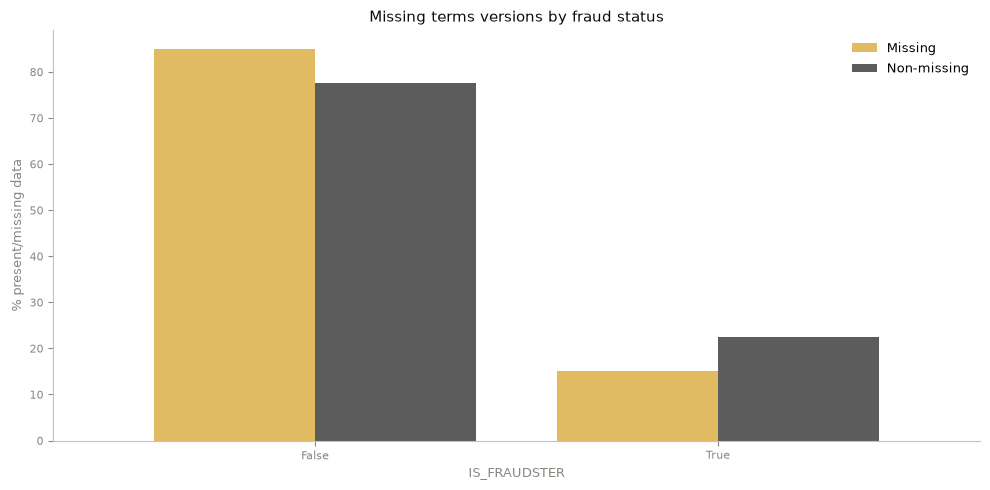

In [124]:
# PLOT
_, ax = plt.subplots(figsize=(10, 5))

colors = ["#d2970d", "#040404"]

ct_terms_missed.plot(kind='bar', width=0.8, color=colors, ax=ax, alpha=0.65)

# ax.grid(axis='y', color='#e1e0d9', linewidth=0.1, zorder=0)
ax.set_xlabel('IS_FRAUDSTER', fontsize=9, color='#898781')
ax.set_ylabel('% present/missing data', fontsize=9, color='#898781')
ax.set_title('Missing terms versions by fraud status', fontsize=11, color='#0b0b0b')
ax.tick_params(axis='both', labelsize=8, colors='#898781')
ax.tick_params(axis='x', labelrotation=0)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('#c3c2b7')
ax.legend(['Missing', 'Non-missing'], frameon=False, fontsize=9)
ax.figure.tight_layout()

plt.show()
# add percantages on bars!!!

In [72]:
# so among fraudsters 22% missed TERMS_VERSION, isn't seen like random. Let's just populate it with "missing" string
u_clean.TERMS_VERSION = u_clean.TERMS_VERSION.fillna('missing')


### STATE

In [73]:
u_clean.STATE.unique()

<StringArray>
['ACTIVE', 'LOCKED']
Length: 2, dtype: str

In [74]:
ct_ustate = pd.crosstab(u_clean.STATE, u_clean.IS_FRAUDSTER, normalize=True).sort_values(True, ascending=False)


<Axes: title={'center': 'feature STATE'}, xlabel='State', ylabel='Proportion'>

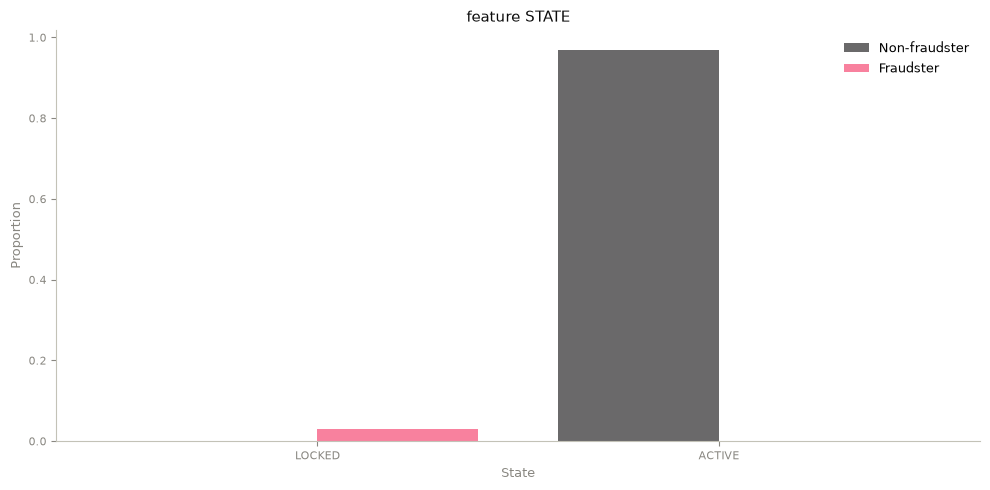

In [75]:
# Data Leakage 
# we can notice that STATE is perfectly correlated with IS_FRAUDSTER, so we have to delete this featere for sure.
plot_fraud_crosstab(ct_ustate, xlabel='State', ylabel='Proportion',
                     title='feature STATE')

In [76]:
# we can notice that STATE is perfectly correlated with IS_FRAUDSTER, so we have to delete this featere for sure.
u_clean = u_clean.drop('STATE', axis=1)

#### COUNTRY

<Axes: title={'center': 'Top 10 countries'}, xlabel='Country', ylabel='% of users'>

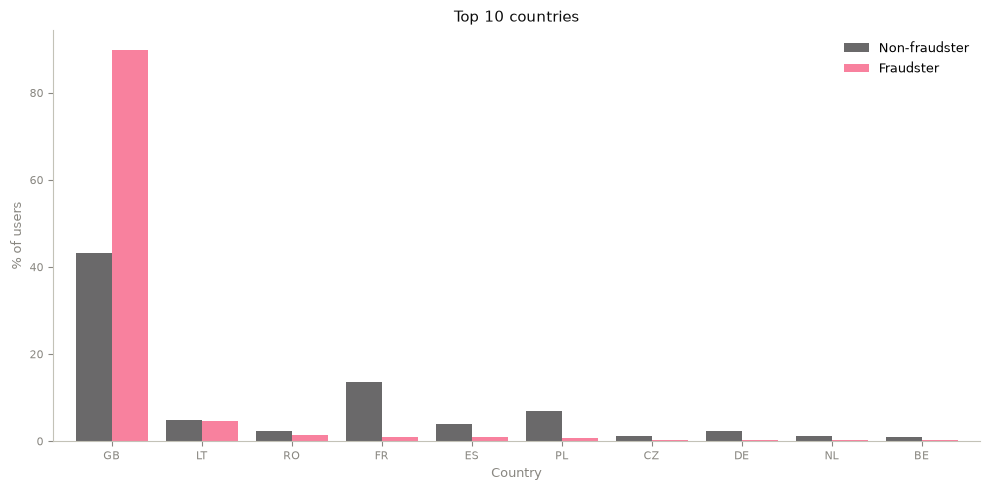

In [77]:
ct_country = ((pd.crosstab(u_clean.COUNTRY, u_clean.IS_FRAUDSTER, normalize='columns')*100)
    .sort_values(True, ascending=False)
    .reset_index()
    .head(10))
    
plot_fraud_crosstab(ct_country.set_index('COUNTRY'), xlabel='Country', ylabel='% of users',
                     title='Top 10 countries')

### BIRTH_YEAR

In [78]:
u_clean.BIRTH_YEAR.dtype

dtype('int64')

In [79]:
u_clean.BIRTH_YEAR.unique()

array([1971, 1982, 1973, 1986, 1989, 1979, 1992, 1983, 1980, 1995, 1978,
       1988, 1967, 1981, 1950, 1987, 1994, 1966, 1999, 1963, 1984, 1974,
       1997, 1991, 1993, 1990, 1998, 1976, 1954, 1964, 1962, 1972, 1970,
       1996, 1957, 1975, 1965, 1977, 1968, 1955, 2000, 1961, 1969, 1985,
       1960, 1952, 1944, 1958, 1959, 1947, 1953, 1951, 1949, 1942, 1945,
       1956, 1935, 1943, 1946, 1948, 1930, 1941, 1928, 1931, 1937, 1929,
       1940, 1936, 1927])

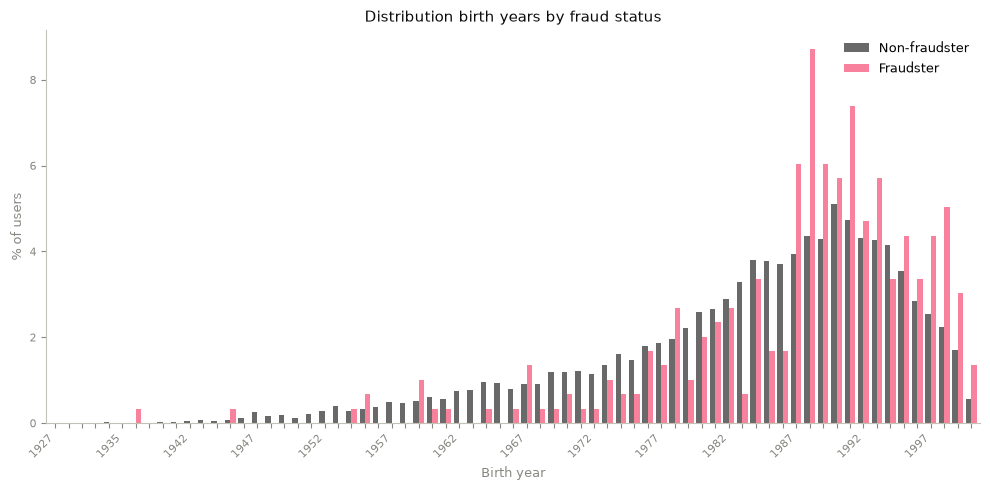

In [144]:
ct_byear = (pd.crosstab(u_clean.BIRTH_YEAR, u_clean.IS_FRAUDSTER, normalize='columns')
    .sort_values('BIRTH_YEAR', ascending=False)
    .sort_index()
)*100
ax = plot_fraud_crosstab(ct_byear, xlabel='Birth year', ylabel='% of users',
                          title='Distribution birth years by fraud status')

# 69 distinct years is too many x-ticks to show at once -- keep every 5th, drop the rest
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 == 0:
        label.set_rotation(45)
        label.set_ha('right')
    else:
        label.set_visible(False)
ax.figure.tight_layout()

In [80]:
# there are some really little anomaly on the very left. but generally we see how fraudsters concentrated in the period from 1987.
# although the nr of customers also increased it still quite obvious cluster
u_clean.BIRTH_YEAR.describe()

count    9944.000000
mean     1983.553298
std        11.350379
min      1927.000000
25%      1978.000000
50%      1986.000000
75%      1992.000000
max      2000.000000
Name: BIRTH_YEAR, dtype: float64

### KYC

In [81]:
u_clean.KYC.unique()

<StringArray>
['PASSED', 'NONE', 'FAILED', 'PENDING']
Length: 4, dtype: str

<Axes: title={'center': 'KYC status distribution'}, xlabel='KYC status', ylabel='Proportion'>

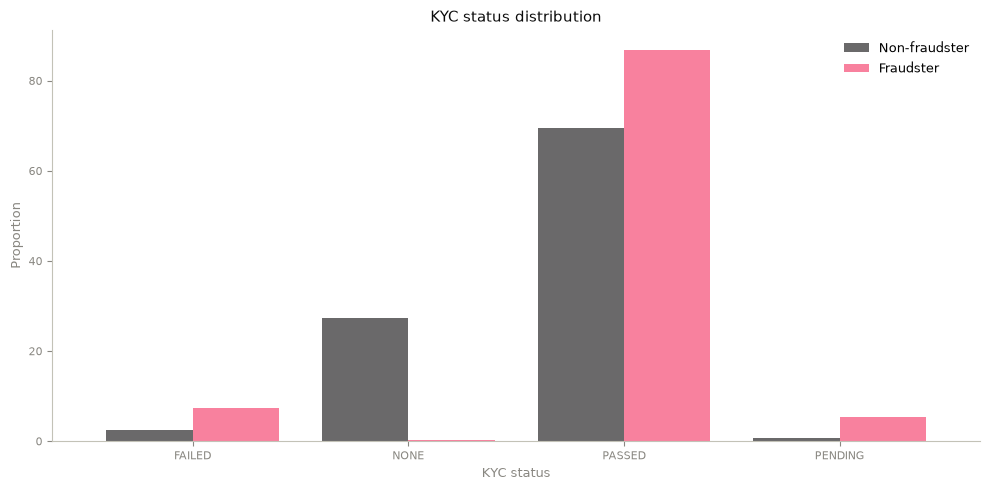

In [82]:
ct_kyc = pd.crosstab(u_clean.KYC, u_clean.IS_FRAUDSTER, normalize='columns')*100
plot_fraud_crosstab(ct_kyc, xlabel='KYC status', ylabel='Proportion',
                     title='KYC status distribution')


In [83]:
ct_kyc

IS_FRAUDSTER,False,True
KYC,,
FAILED,2.571014,7.382550
NONE,27.265188,0.335570
PASSED,69.562513,86.912752
PENDING,0.601286,5.369128


In [149]:
#  FAILED (7.4% vs 2.6%) and PENDING (5.4% vs 0.6%) are both 
# notably overrepresented among fraudsters. Interestingly NONE is 0.3% for fraudsters vs 8.75% for 
# legitimate users, meaning every fraud account in this data went through some KYC attempt while a chunk of normal users never did one at all.
# PASSED for fraudsters is 87% and normal users 70%. 
# So it's like big part of the percentage of normal users from NONE is in PASSED part for fraudsters. 
# FAILED/PENDING KYC status looks like potential fraud signal.


In [84]:
u_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       9944 non-null   str           
 1   HAS_EMAIL                9944 non-null   int64         
 2   PHONE_COUNTRY            9944 non-null   str           
 3   IS_FRAUDSTER             9944 non-null   bool          
 4   TERMS_VERSION            9944 non-null   str           
 5   CREATED_DATE             9944 non-null   datetime64[us]
 6   COUNTRY                  9944 non-null   str           
 7   BIRTH_YEAR               9944 non-null   int64         
 8   KYC                      9944 non-null   str           
 9   FAILED_SIGN_IN_ATTEMPTS  9944 non-null   int64         
dtypes: bool(1), datetime64[us](1), int64(3), str(5)
memory usage: 709.0 KB


### FAILED_SIGN_IN_ATTEMPTS

In [85]:
u_clean.FAILED_SIGN_IN_ATTEMPTS.unique()

array([0, 1, 3, 2, 6])

In [86]:
pd.crosstab(u_clean.FAILED_SIGN_IN_ATTEMPTS, u_clean.IS_FRAUDSTER)

IS_FRAUDSTER,False,True
FAILED_SIGN_IN_ATTEMPTS,,
0,9600,295
1,24,1
2,18,2
3,3,0
6,1,0


In [87]:
pd.crosstab(u_clean.FAILED_SIGN_IN_ATTEMPTS, u_clean.IS_FRAUDSTER, normalize='columns')*100 
# pretty similar disctribution for both fraud statuses

IS_FRAUDSTER,False,True
FAILED_SIGN_IN_ATTEMPTS,,
0,99.523118,98.993289
1,0.248808,0.335570
2,0.186606,0.671141
3,0.031101,0.000000
6,0.010367,0.000000


In [88]:
fraud_trans.columns

Index(['CURRENCY', 'AMOUNT', 'STATE', 'CREATED_DATE', 'MERCHANT_CATEGORY',
       'MERCHANT_COUNTRY', 'ENTRY_METHOD', 'USER_ID', 'TYPE', 'SOURCE',
       'TRANS_ID', 'AMOUNT_USD', 'datetime', 'date', 'ID', 'IS_FRAUDSTER',
       'CCY', 'EXPONENT', 'IS_CRYPTO'],
      dtype='str')

In [89]:
# fraud_trans = (fraud_trans.assign(date = lambda d: d['datetime'].dt.date))

In [90]:
frauds_daily = (fraud_trans
                    .groupby('date')
                    .size()
                    .reset_index(name='amount'))
frauds_daily = frauds_daily.set_index('date')
frauds_daily.head()

,amount
date,
2016-03-15,2
2016-11-02,2
2017-01-10,1
2017-01-11,1
2017-01-17,1


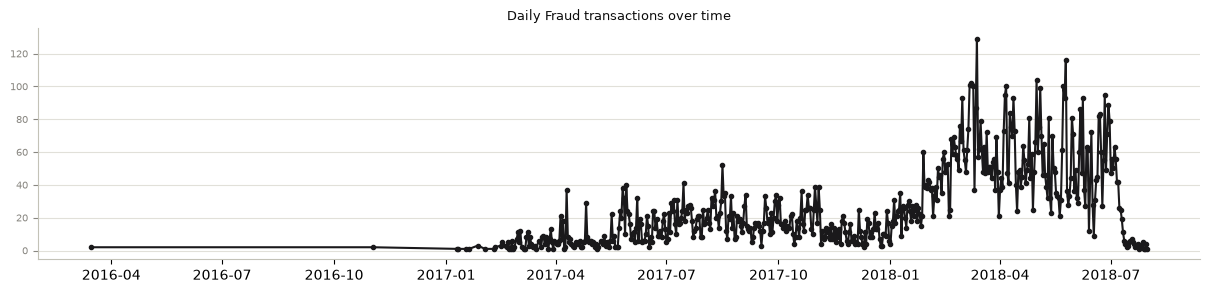

In [91]:
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(frauds_daily.index, frauds_daily.values, color="#1a191bff", linewidth=1.5,
        marker='o', markersize=3)
ax.set_title('Daily Fraud transactions over time', fontsize=9, color='#0b0b0b')
ax.tick_params(axis='y', labelsize=7, colors='#898781')
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')


In [92]:
daily = (pd.crosstab(t_clean['date'], t_clean['IS_FRAUDSTER'])
           .fillna(0))

daily.head(3)


IS_FRAUDSTER,False,True
date,,
2016-01-03,1,0
2016-01-04,6,0
2016-01-05,2,0


In [93]:
daily['total'] = daily[False] + daily[True]
daily['fraud_rate'] = daily[True] / daily['total'] * 100
daily['fraud_per_10k'] = daily[True] / daily['total'] * 10_000

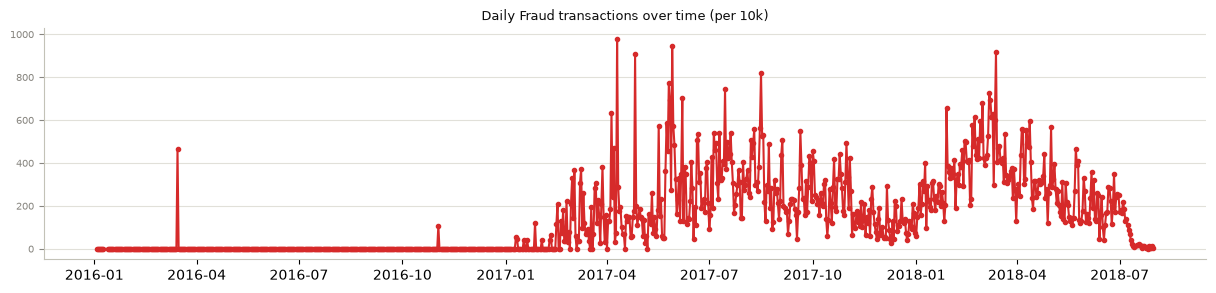

In [94]:
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(daily['fraud_per_10k'].index, daily['fraud_per_10k'].values, color='#d62a2a', linewidth=1.5,
        marker='o', markersize=3)
ax.set_title('Daily Fraud transactions over time (per 10k)', fontsize=9, color='#0b0b0b')
ax.tick_params(axis='y', labelsize=7, colors='#898781')
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')


In [95]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily.index, y=daily['fraud_per_10k'],
    mode='lines', name='Daily', opacity=0.3
))
fig.add_trace(go.Scatter(
    x=daily.index, y=daily['fraud_per_10k'].rolling(14, center=True).mean(),
    mode='lines', name='14-day rolling mean', line=dict(width=3)
))
fig.add_hline(y=1, line_dash='dash', line_color='gray',
              annotation_text='Expected')

fig.update_layout(
    title='Fraud relative to transaction volume',
    yaxis_title='Actual / expected fraud',
    hovermode='x unified',
    height=500
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [96]:
# before we connect transactions and users, let's check common names in columns and rename:
t_clean.columns.intersection(u_clean.columns)

Index(['CREATED_DATE', 'ID', 'IS_FRAUDSTER'], dtype='str')

In [97]:
t_clean = t_clean.drop(['USER_ID'], axis=1)
t_clean.columns

Index(['CURRENCY', 'AMOUNT', 'STATE', 'CREATED_DATE', 'MERCHANT_CATEGORY',
       'MERCHANT_COUNTRY', 'ENTRY_METHOD', 'TYPE', 'SOURCE', 'TRANS_ID',
       'AMOUNT_USD', 'datetime', 'date', 'ID', 'IS_FRAUDSTER', 'IS_CRYPTO'],
      dtype='str')

In [98]:
t_clean = t_clean.rename(columns={'CREATED_DATE': 'CREATED_DATE_TRANS'})

In [99]:
u_clean = u_clean.rename(columns={'CREATED_DATE': 'CREATED_DATE_ACC'})

In [100]:
t_clean.to_csv('t_clean.csv', index=False)
u_clean.to_csv('u_clean.csv', index=False)

### Check correlation for a chosen subset of variables

For spot-checking a handful of columns (e.g. before adding a new feature) without
rendering the full matrix — returns a small table of pairwise correlations instead.

In [54]:
def check_correlation(data, columns, threshold=0.0):
    """Return pairwise correlations among the given columns, sorted by |correlation|."""
    corr = data[columns].corr()
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .rename('correlation')
            .reset_index()
            .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
    )
    return (pairs[pairs['correlation'].abs() > threshold]
            .sort_values('correlation', key=lambda s: s.abs(), ascending=False)
            .reset_index(drop=True))

In [514]:
# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # # Use scaled data for LR, original for tree-based
    # if name == 'Logistic Regression':
    #     model.fit(X_train_scaled, y_train)
    #     y_pred = model.predict(X_test_scaled)
    #     y_prob = model.predict_proba(X_test_scaled)[:, 1]
    # else:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision, 
        'precision': precision,
        'recall': recall
    }
    
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  Average Precision: {avg_precision:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")


Training Logistic Regression...
  ROC-AUC: 0.9584
  Average Precision: 0.6995
  Precision: 0.7447
  Recall: 0.5932

Training Random Forest...
  ROC-AUC: 0.9689
  Average Precision: 0.7335
  Precision: 0.9130
  Recall: 0.3559

Training Gradient Boosting...
  ROC-AUC: 0.9748
  Average Precision: 0.7846
  Precision: 0.8571
  Recall: 0.6102


In [502]:
y_pred[:5]

array([0, 0, 0, 0, 0])

## XGBoost, LightGBM, and CatBoost,